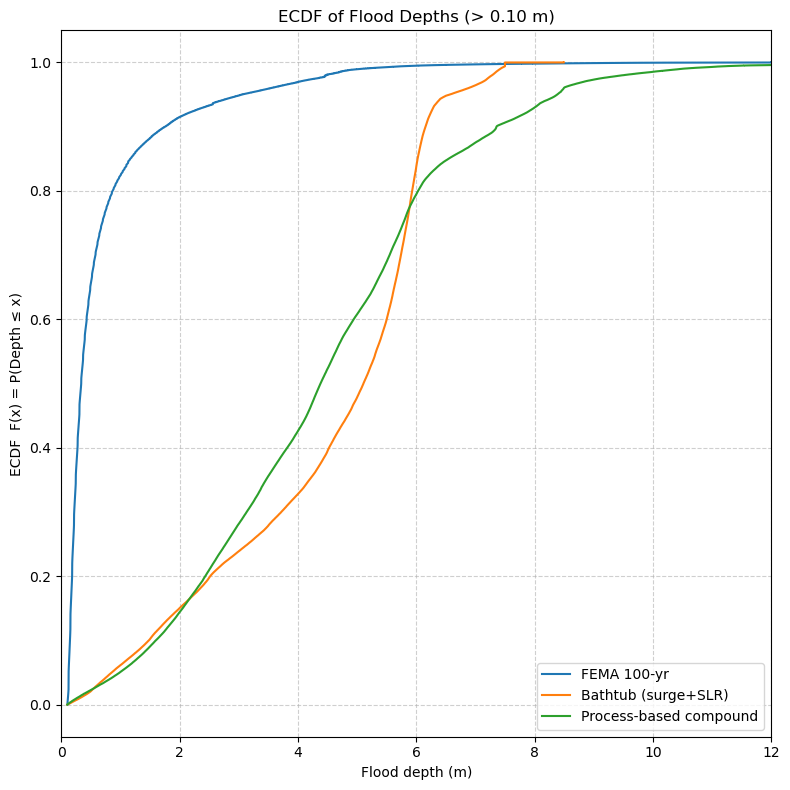

In [4]:
import os, zipfile, warnings
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from rasterio.warp import reproject, Resampling, transform_bounds
from rasterio.transform import from_origin
import math

# ============ USER INPUTS ============
THRESHOLD = 0.10  # meters; inundated if depth > THRESHOLD

# Rasters
r_fema     = r"D:\Phd Research\GIS\Raster\Fema_raster_100yr_25m.tif"
r_bathtub  = r"D:\Phd Research\Final_Raster\Bathtub_depth_100yr_surge_SLR.tif"
r_compound = r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_stat.tif"

# Boundary shapefile (zip)
boundary_zip = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"
extract_dir  = r"D:\Phd Research\GIS\Shape\unzipped"

# If True: compute ECDF over common-wet footprint via a common grid
COMMON_FOOTPRINT = False
# Common-grid CRS and resolution (used only if COMMON_FOOTPRINT=True)
TARGET_CRS = "EPSG:4326"      # or "EPSG:32614" for meters
TARGET_RES = 0.0005           # degrees/pixel if EPSG:4326; use e.g., 25.0 if in meters
# =====================================

# ---------- Helpers ----------
def ensure_unzipped(zip_path, out_dir):
    if not os.path.isdir(out_dir) or not any(f.endswith(".shp") for f in os.listdir(out_dir)):
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(out_dir)
    shp = [os.path.join(out_dir, f) for f in os.listdir(out_dir) if f.endswith(".shp")]
    if not shp:
        raise FileNotFoundError("No .shp found after unzip.")
    return shp[0]

def load_depths_over_boundary(raster_path, gdf_boundary, threshold=THRESHOLD):
    """Return 1D array of depths > threshold, clipped to boundary, for one raster."""
    with rasterio.open(raster_path) as src:
        bnd = gdf_boundary.to_crs(src.crs)
        out, _ = mask(src, bnd.geometry, crop=True, filled=False, all_touched=True)
        arr = out[0]  # MaskedArray
        valid = ~arr.mask & np.isfinite(arr)
        wet = valid & (arr > threshold)
        data = arr[wet].compressed()
    return data

def ecdf(data_1d):
    x = np.sort(data_1d)
    n = x.size
    y = np.arange(1, n + 1) / n
    return x, y

# --- Common grid helpers (used only if COMMON_FOOTPRINT=True) ---
def union_bounds_in_target(profiles, target_crs):
    xs_min, ys_min, xs_max, ys_max = [], [], [], []
    for p in profiles:
        h, w = p["height"], p["width"]
        left, bottom, right, top = rasterio.transform.array_bounds(h, w, p["transform"])
        l, b, r, t = transform_bounds(p["crs"], target_crs, left, bottom, right, top, densify_pts=21)
        xs_min.append(l); ys_min.append(b); xs_max.append(r); ys_max.append(t)
    return min(xs_min), min(ys_min), max(xs_max), max(ys_max)

def make_grid(left, bottom, right, top, res):
    width  = int(math.ceil((right - left) / res))
    height = int(math.ceil((top - bottom) / res))
    transform = from_origin(left, top, res, res)
    return transform, width, height

def reproj_arr(src_path, dst_transform, dst_crs, dst_w, dst_h, resampling=Resampling.bilinear):
    """Reproject a continuous depth raster to the common grid."""
    with rasterio.open(src_path) as src:
        dst = np.zeros((dst_h, dst_w), dtype="float32")
        reproject(
            source=rasterio.band(src, 1),
            destination=dst,
            src_transform=src.transform, src_crs=src.crs,
            dst_transform=dst_transform, dst_crs=dst_crs,
            resampling=resampling,
        )
        return dst

def reproj_mask(src_path, threshold, dst_transform, dst_crs, dst_w, dst_h):
    """Reproject to common grid then threshold -> wet mask (0/1)."""
    arr = reproj_arr(src_path, dst_transform, dst_crs, dst_w, dst_h, resampling=Resampling.bilinear)
    wet = (np.isfinite(arr) & (arr > threshold)).astype("uint8")
    return wet, arr
# --------------------------------------

# Load boundary
shp_path = ensure_unzipped(boundary_zip, extract_dir)
gdf_boundary = gpd.read_file(shp_path)

if not COMMON_FOOTPRINT:
    # ---- Simple mode: ECDF per raster over its own wet area (>THRESHOLD), clipped to boundary ----
    depths_fema     = load_depths_over_boundary(r_fema,     gdf_boundary, THRESHOLD)
    depths_bathtub  = load_depths_over_boundary(r_bathtub,  gdf_boundary, THRESHOLD)
    depths_compound = load_depths_over_boundary(r_compound, gdf_boundary, THRESHOLD)

    curves = []
    for name, data in [("FEMA 100-yr", depths_fema),
                       ("Bathtub (surge+SLR)", depths_bathtub),
                       ("Process-based compound", depths_compound)]:
        if data.size == 0:
            print(f"[WARN] No wet pixels (> {THRESHOLD} m) for {name}. Skipping.")
            continue
        x, y = ecdf(data)
        curves.append((name, x, y))

else:
    # ---- Common footprint mode: reproject all to a common grid and use the intersection of wet masks ----
    # Gather profiles
    profs = []
    for pth in [r_fema, r_bathtub, r_compound]:
        with rasterio.open(pth) as s:
            profs.append({"crs": s.crs, "transform": s.transform, "width": s.width, "height": s.height})

    left, bottom, right, top = union_bounds_in_target(profs, TARGET_CRS)
    dst_transform, dst_w, dst_h = make_grid(left, bottom, right, top, TARGET_RES)

    wet_fema,     arr_fema     = reproj_mask(r_fema,     THRESHOLD, dst_transform, TARGET_CRS, dst_w, dst_h)
    wet_bathtub,  arr_bathtub  = reproj_mask(r_bathtub,  THRESHOLD, dst_transform, TARGET_CRS, dst_w, dst_h)
    wet_compound, arr_compound = reproj_mask(r_compound, THRESHOLD, dst_transform, TARGET_CRS, dst_w, dst_h)

    inter = (wet_fema == 1) & (wet_bathtub == 1) & (wet_compound == 1)

    depths_fema     = arr_fema[inter]
    depths_bathtub  = arr_bathtub[inter]
    depths_compound = arr_compound[inter]

    curves = []
    for name, data in [("FEMA 100-yr", depths_fema),
                       ("Bathtub (surge+SLR)", depths_bathtub),
                       ("Process-based compound", depths_compound)]:
        data = data[np.isfinite(data)]
        if data.size == 0:
            print(f"[WARN] No common-wet pixels for {name}. Skipping.")
            continue
        x, y = ecdf(data)
        curves.append((name, x, y))

# ---- Plot ECDFs ----
XMAX = 12.0  # meters

plt.figure(figsize=(8, 8))
for name, x, y in curves:
    plt.step(x, y, where="post", label=name)

plt.xlabel("Flood depth (m)")
plt.ylabel("ECDF  F(x) = P(Depth ≤ x)")
plt.title(f"ECDF of Flood Depths (> {THRESHOLD:.2f} m)"
          + (" — Common wet footprint" if COMMON_FOOTPRINT else ""))
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.xlim(0, XMAX)           # <<< keep X axis up to 12 m
plt.tight_layout()
plt.show()


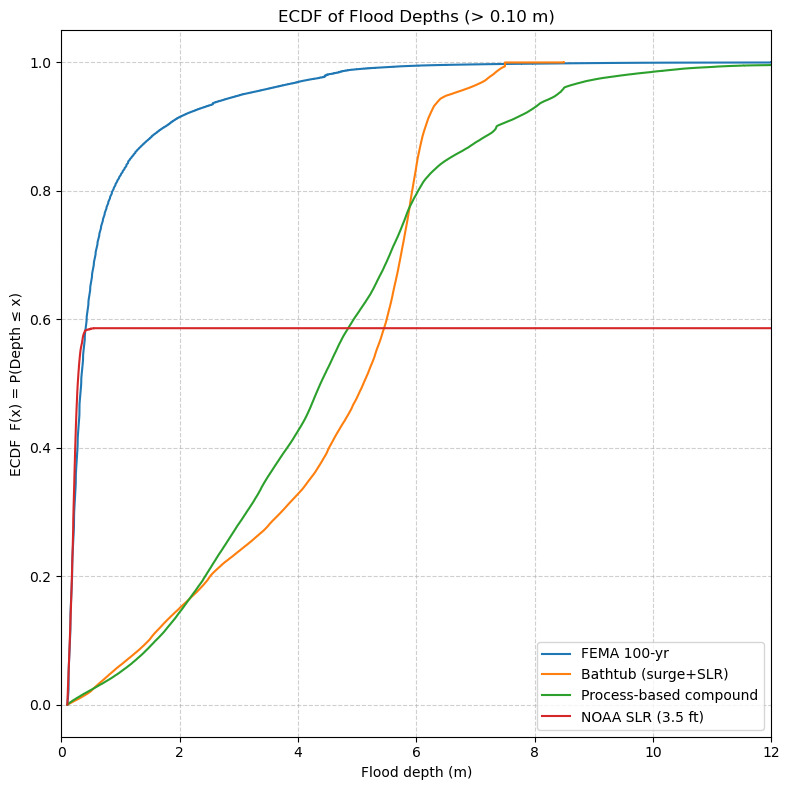

In [10]:
import os, zipfile, warnings
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from rasterio.warp import reproject, Resampling, transform_bounds
from rasterio.transform import from_origin
import math

# ============ USER INPUTS ============
THRESHOLD = 0.10  # meters; inundated if depth > THRESHOLD

# Rasters
r_fema     = r"D:\Phd Research\GIS\Raster\Fema_raster_100yr_25m.tif"
#r_bathtub  = r"D:\Phd Research\Final_Raster\Bathtub_depth_100yr_surge_SLR.tif"
r_bathtub = r"D:\Phd Research\Final_Raster\Bathtub_depth_100yr_surge_SLR_nonnegative.tif"
r_compound = r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_stat.tif"

r_noaa     = r"C:\Users\sahad2\Research_data\SLR_Depth_Raster_NOAA\SLR_depth_3_5ft_tx_200m_UTM_m.tif"

# Boundary shapefile (zip)
boundary_zip = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"
extract_dir  = r"D:\Phd Research\GIS\Shape\unzipped"

# If True: compute ECDF over common-wet footprint via a common grid
COMMON_FOOTPRINT = False
# Common-grid CRS and resolution (used only if COMMON_FOOTPRINT=True)
TARGET_CRS = "EPSG:4326"      # or "EPSG:32614" for meters
TARGET_RES = 0.0005           # degrees/pixel if EPSG:4326; use e.g., 25.0 if in meters
# =====================================

# ---- Per-raster scale factors (to meters) ----
# If your NOAA raster is already meters, set this to 1.0.
SCALE_FACTORS = {
    r_fema: 1.0,
    r_bathtub: 1.0,
    r_compound: 1.0,
    r_noaa: 1.0,  
}

# ---------- Helpers ----------
def ensure_unzipped(zip_path, out_dir):
    if not os.path.isdir(out_dir) or not any(f.endswith(".shp") for f in os.listdir(out_dir)):
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(out_dir)
    shp = [os.path.join(out_dir, f) for f in os.listdir(out_dir) if f.endswith(".shp")]
    if not shp:
        raise FileNotFoundError("No .shp found after unzip.")
    return shp[0]

def load_depths_over_boundary(raster_path, gdf_boundary, threshold=THRESHOLD, scale=1.0):
    """Return 1D array of depths (> threshold), clipped to boundary, for one raster.
       Applies 'scale' to convert units to meters before thresholding."""
    with rasterio.open(raster_path) as src:
        bnd = gdf_boundary.to_crs(src.crs)
        out, _ = mask(src, bnd.geometry, crop=True, filled=False, all_touched=True)
        arr = out[0]  # MaskedArray
        arr = arr.astype('float32') * scale
        valid = ~arr.mask & np.isfinite(arr)
        wet = valid & (arr > threshold)
        data = arr[wet].compressed()
    return data

def ecdf(data_1d):
    x = np.sort(data_1d)
    n = x.size
    y = np.arange(1, n + 1) / n
    return x, y

# --- Common grid helpers (used only if COMMON_FOOTPRINT=True) ---
def union_bounds_in_target(profiles, target_crs):
    xs_min, ys_min, xs_max, ys_max = [], [], [], []
    for p in profiles:
        h, w = p["height"], p["width"]
        left, bottom, right, top = rasterio.transform.array_bounds(h, w, p["transform"])
        l, b, r, t = transform_bounds(p["crs"], target_crs, left, bottom, right, top, densify_pts=21)
        xs_min.append(l); ys_min.append(b); xs_max.append(r); ys_max.append(t)
    return min(xs_min), min(ys_min), max(xs_max), max(ys_max)

def make_grid(left, bottom, right, top, res):
    width  = int(math.ceil((right - left) / res))
    height = int(math.ceil((top - bottom) / res))
    transform = from_origin(left, top, res, res)
    return transform, width, height

def reproj_arr(src_path, dst_transform, dst_crs, dst_w, dst_h, resampling=Resampling.bilinear, scale=1.0):
    """Reproject a continuous depth raster to the common grid, then apply scale to meters."""
    with rasterio.open(src_path) as src:
        dst = np.zeros((dst_h, dst_w), dtype="float32")
        reproject(
            source=rasterio.band(src, 1),
            destination=dst,
            src_transform=src.transform, src_crs=src.crs,
            dst_transform=dst_transform, dst_crs=dst_crs,
            resampling=resampling,
        )
        dst *= scale
        return dst

def reproj_mask(src_path, threshold, dst_transform, dst_crs, dst_w, dst_h, scale=1.0):
    """Reproject to common grid, scale to meters, then threshold -> wet mask (0/1)."""
    arr = reproj_arr(src_path, dst_transform, dst_crs, dst_w, dst_h,
                     resampling=Resampling.bilinear, scale=scale)
    wet = (np.isfinite(arr) & (arr > threshold)).astype("uint8")
    return wet, arr
# --------------------------------------

# Load boundary
shp_path = ensure_unzipped(boundary_zip, extract_dir)
gdf_boundary = gpd.read_file(shp_path)

# List of rasters & labels
RASTERS = [
    (r_fema,     "FEMA 100-yr"),
    (r_bathtub,  "Bathtub (surge+SLR)"),
    (r_compound, "Process-based compound"),
    (r_noaa,     "NOAA SLR (3.5 ft)"),
]

if not COMMON_FOOTPRINT:
    # ---- Simple mode: ECDF per raster over its own wet area (>THRESHOLD), clipped to boundary ----
    curves = []
    for pth, label in RASTERS:
        sc = SCALE_FACTORS.get(pth, 1.0)
        data = load_depths_over_boundary(pth, gdf_boundary, THRESHOLD, scale=sc)
        if data.size == 0:
            print(f"[WARN] No wet pixels (> {THRESHOLD} m) for {label}. Skipping.")
            continue
        x, y = ecdf(data)
        curves.append((label, x, y))

else:
    # ---- Common footprint mode: reproject all to a common grid and use the intersection of wet masks ----
    # Gather profiles
    profs = []
    for pth, _ in RASTERS:
        with rasterio.open(pth) as s:
            profs.append({"crs": s.crs, "transform": s.transform, "width": s.width, "height": s.height})

    left, bottom, right, top = union_bounds_in_target(profs, TARGET_CRS)
    dst_transform, dst_w, dst_h = make_grid(left, bottom, right, top, TARGET_RES)

    # Reproject & threshold each, track masks/arrays
    wet_masks = []
    arrays = []
    for pth, _ in RASTERS:
        sc = SCALE_FACTORS.get(pth, 1.0)
        wet, arr = reproj_mask(pth, THRESHOLD, dst_transform, TARGET_CRS, dst_w, dst_h, scale=sc)
        wet_masks.append(wet == 1)
        arrays.append(arr)

    # Intersection of all wet areas
    inter = np.logical_and.reduce(wet_masks)

    # Build curves
    curves = []
    for (pth, label), arr in zip(RASTERS, arrays):
        data = arr[inter]
        data = data[np.isfinite(data)]
        if data.size == 0:
            print(f"[WARN] No common-wet pixels for {label}. Skipping.")
            continue
        x, y = ecdf(data)
        curves.append((label, x, y))

# ---- Plot ECDFs ----
XMAX = 12.0  # meters

plt.figure(figsize=(8, 8))
for name, x, y in curves:
    plt.step(x, y, where="post", label=name)

plt.xlabel("Flood depth (m)")
plt.ylabel("ECDF  F(x) = P(Depth ≤ x)")
plt.title(f"ECDF of Flood Depths (> {THRESHOLD:.2f} m)"
          + (" — Common wet footprint" if COMMON_FOOTPRINT else ""))
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.xlim(0, XMAX)
plt.tight_layout()
plt.show()


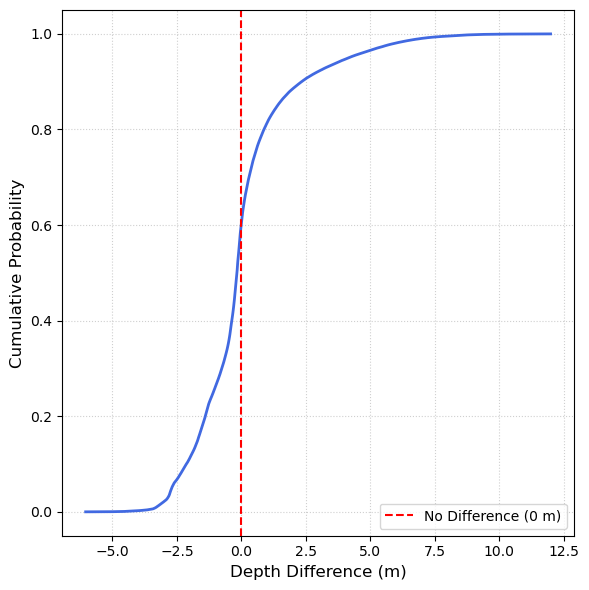

In [4]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# -------- USER INPUT --------
r_diff = r"D:\Phd Research\Final_Raster\diff_process_bath_100yr.tif"

# -------- READ RASTER --------
with rasterio.open(r_diff) as src:
    diff = src.read(1).astype(float)
    nodata = src.nodata if src.nodata is not None else -9999.0

# -------- CLEAN DATA --------
mask = np.isfinite(diff) & (diff != nodata)
diff_valid = diff[mask]

# Optional: clip unrealistic outliers
diff_valid = diff_valid[(diff_valid >= -12) & (diff_valid <= 12)]

# print(f"Valid pixels used in CDF: {diff_valid.size:,}")

# -------- COMPUTE CDF --------
sorted_diff = np.sort(diff_valid)
cdf = np.arange(1, len(sorted_diff) + 1) / len(sorted_diff)

# -------- PLOT --------
plt.figure(figsize=(6,6))
plt.plot(sorted_diff, cdf, color='royalblue', linewidth=2)

# Add vertical line at 0 (no difference)
plt.axvline(0, color='red', linestyle='--', linewidth=1.5, label='No Difference (0 m)')

# Labels, grid, and title
# plt.title("Cumulative Distribution of Depth Difference\n(Process-based – Bathtub, 100-year)", fontsize=13)
plt.xlabel("Depth Difference (m)", fontsize=12)
plt.ylabel("Cumulative Probability", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


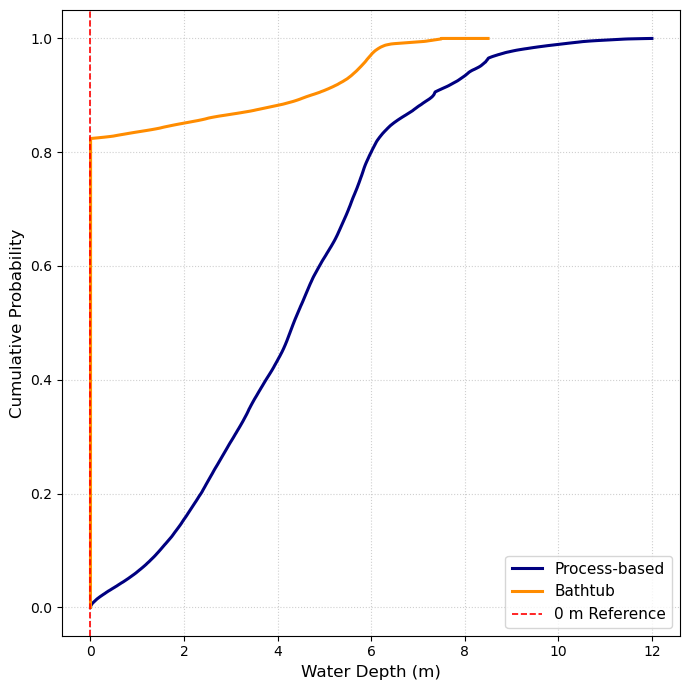

In [5]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# -------- USER INPUT --------
r_process = r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_stat.tif"
r_bathtub = r"D:\Phd Research\Final_Raster\Bathtub_depth_100yr_surge_SLR.tif"

# -------- FUNCTION TO READ AND CLEAN RASTER --------
def read_valid_depths(path, min_val=0.0, max_val=12.0):
    """Read raster and return flattened array of valid water depths within range."""
    with rasterio.open(path) as src:
        arr = src.read(1).astype(float)
        nodata = src.nodata if src.nodata is not None else -9999
        mask = np.isfinite(arr) & (arr != nodata)
        vals = arr[mask]
        vals = vals[(vals >= min_val) & (vals <= max_val)]
    return vals

# -------- READ DATA --------
depth_process = read_valid_depths(r_process)
depth_bathtub = read_valid_depths(r_bathtub)

# -------- COMPUTE CDFs --------
def compute_cdf(data):
    sorted_vals = np.sort(data)
    cdf = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
    return sorted_vals, cdf

x_process, y_process = compute_cdf(depth_process)
x_bathtub, y_bathtub = compute_cdf(depth_bathtub)

# -------- PLOT --------
plt.figure(figsize=(7, 7))

plt.plot(x_process, y_process, color='navy', linewidth=2.2, label='Process-based')
plt.plot(x_bathtub, y_bathtub, color='darkorange', linewidth=2.2, label='Bathtub')

# Reference lines
plt.axvline(0, color='red', linestyle='--', linewidth=1.2, label='0 m Reference')

# Axis labels and style
plt.xlabel("Water Depth (m)", fontsize=12)
plt.ylabel("Cumulative Probability", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, loc='lower right', fontsize=11)
plt.tight_layout()

plt.show()


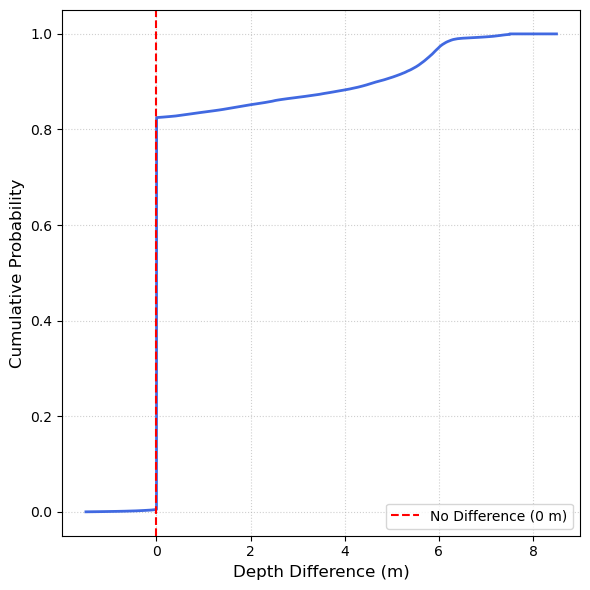

In [6]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# -------- USER INPUT --------
r_diff = r"D:\Phd Research\Final_Raster\Bathtub_depth_100yr_surge_SLR.tif"

# -------- READ RASTER --------
with rasterio.open(r_diff) as src:
    diff = src.read(1).astype(float)
    nodata = src.nodata if src.nodata is not None else -9999.0

# -------- CLEAN DATA --------
mask = np.isfinite(diff) & (diff != nodata)
diff_valid = diff[mask]

# Optional: clip unrealistic outliers
diff_valid = diff_valid[(diff_valid >= -12) & (diff_valid <= 12)]

# print(f"Valid pixels used in CDF: {diff_valid.size:,}")

# -------- COMPUTE CDF --------
sorted_diff = np.sort(diff_valid)
cdf = np.arange(1, len(sorted_diff) + 1) / len(sorted_diff)

# -------- PLOT --------
plt.figure(figsize=(6,6))
plt.plot(sorted_diff, cdf, color='royalblue', linewidth=2)

# Add vertical line at 0 (no difference)
plt.axvline(0, color='red', linestyle='--', linewidth=1.5, label='No Difference (0 m)')

# Labels, grid, and title
# plt.title("Cumulative Distribution of Depth Difference\n(Process-based – Bathtub, 100-year)", fontsize=13)
plt.xlabel("Depth Difference (m)", fontsize=12)
plt.ylabel("Cumulative Probability", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()
